In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt



In [ ]:
model = hub.load("https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2")

In [ ]:
!pip install tensorflow tensorflow-hub opencv-python matplotlib numpy


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test.jpeg to test.jpeg


In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
model = hub.load("https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2")

In [ ]:
image_path = "test.jpg"

In [ ]:
print(image_path)

test.jpg


In [ ]:
!ls

sample_data  test.jpeg


In [ ]:
image_path = "test.jpeg"

image = cv2.imread(image_path)

if image is None:
    print("Image not found. Please check file name.")
else:
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [ ]:
input_tensor = tf.convert_to_tensor(image)
input_tensor = input_tensor[tf.newaxis, ...]


In [ ]:
detections = model(input_tensor)

In [ ]:
boxes = detections['detection_boxes'][0].numpy()
scores = detections['detection_scores'][0].numpy()
classes = detections['detection_classes'][0].numpy().astype(int)

height, width, _ = image.shape


In [ ]:
for i in range(len(scores)):

    if scores[i] > 0.5:

        ymin, xmin, ymax, xmax = boxes[i]

        xmin = int(xmin * width)
        xmax = int(xmax * width)
        ymin = int(ymin * height)
        ymax = int(ymax * height)

        cv2.rectangle(image,(xmin,ymin),(xmax,ymax),(255,0,0),2)


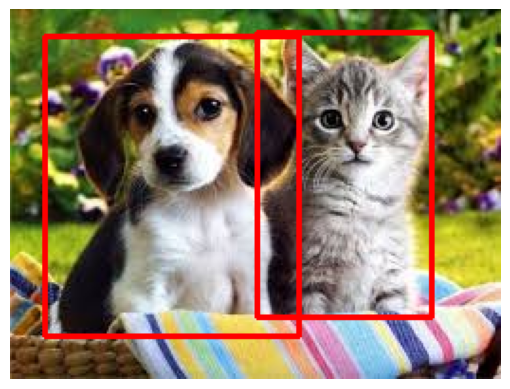

In [ ]:
plt.imshow(image)
plt.axis("off")
plt.show()
